In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install timm opencv-python medpy -q

In [ ]:
!pip install medpy -q

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from timm.models.layers import DropPath

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
class CFG:
    seed = 42
    image_size = 256
    batch_size = 4
    num_workers = 2
    epochs = 100
    lr = 1e-3
    device = "cuda" if torch.cuda.is_available() else "cpu"

    drive_root = "/content/drive/MyDrive/DRIVE"

    image_dir = os.path.join(drive_root, "training", "images")
    mask_dir  = os.path.join(drive_root, "training", "1st_manual")

cfg = CFG()

print("Device:", cfg.device)
print("Image dir:", cfg.image_dir)
print("Mask dir :", cfg.mask_dir)

Device: cpu
Image dir: /content/drive/MyDrive/DRIVE/training/images
Mask dir : /content/drive/MyDrive/DRIVE/training/1st_manual


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

In [ ]:
VALID_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".gif", ".bmp"}

def list_all_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([str(x) for x in folder.iterdir() if x.is_file() and x.suffix.lower() in VALID_EXTS])

image_files = list_all_files(cfg.image_dir)
mask_files  = list_all_files(cfg.mask_dir)

print("Images:", len(image_files))
print("Masks :", len(mask_files))

print("\nSample image files:", image_files[:3])
print("Sample mask files :", mask_files[:3])

Images: 20
Masks : 20

Sample image files: ['/content/drive/MyDrive/DRIVE/training/images/21_training.tif', '/content/drive/MyDrive/DRIVE/training/images/22_training.tif', '/content/drive/MyDrive/DRIVE/training/images/23_training.tif']
Sample mask files : ['/content/drive/MyDrive/DRIVE/training/1st_manual/21_manual1.gif', '/content/drive/MyDrive/DRIVE/training/1st_manual/22_manual1.gif', '/content/drive/MyDrive/DRIVE/training/1st_manual/23_manual1.gif']


In [ ]:
def get_case_id(path):
    name = Path(path).stem.lower()
    name = name.replace("_training", "")
    name = name.replace("_manual1", "")
    name = name.replace("_manual2", "")
    return name

def build_pairs(image_files, mask_files):
    mask_dict = {get_case_id(m): m for m in mask_files}
    pairs = []
    missing = []

    for img in image_files:
        key = get_case_id(img)
        if key in mask_dict:
            pairs.append((img, mask_dict[key]))
        else:
            missing.append(img)

    return pairs, missing

pairs, missing = build_pairs(image_files, mask_files)

print("Matched pairs:", len(pairs))

if missing:
    print("\nMissing masks:")
    for x in missing[:5]:
        print(x)

Matched pairs: 20


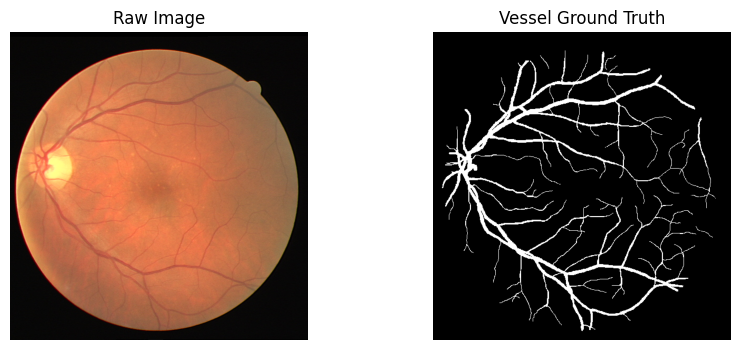

In [ ]:
img_path, mask_path = pairs[0]

img = cv2.imread(img_path, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Vessel Ground Truth")
plt.axis("off")

plt.show()

In [ ]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.3,
    random_state=cfg.seed
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=cfg.seed
)

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))

Train pairs: 14
Validation pairs: 3
Test pairs: 3


In [ ]:
class DriveDataset(Dataset):
    def __init__(self, pairs, image_size=256):
        self.pairs = pairs
        self.image_size = image_size
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.pairs)

    def preprocess_image(self, img):
        # BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # green channel
        green = img[:, :, 1]

        # CLAHE
        green = self.clahe.apply(green)

        # normalize
        green = green.astype(np.float32) / 255.0

        # make 3 channels again
        green = np.stack([green, green, green], axis=0)
        return green

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (self.image_size, self.image_size))
        img = self.preprocess_image(img)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.image_size, self.image_size))
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [ ]:
train_dataset = DriveDataset(train_pairs, cfg.image_size)
val_dataset   = DriveDataset(val_pairs, cfg.image_size)
test_dataset  = DriveDataset(test_pairs, cfg.image_size)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 14
Val dataset  : 3
Test dataset : 3


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 4
Val batches  : 1
Test batches : 1


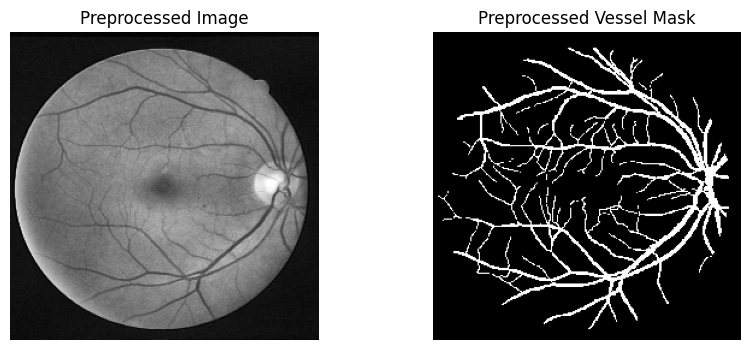

In [ ]:
img, mask = train_dataset[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0).numpy(), cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze().numpy(), cmap="gray")
plt.title("Preprocessed Vessel Mask")
plt.axis("off")

plt.show()

In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target, smooth=1e-6):
        bce = self.bce(pred, target)
        pred_sig = torch.sigmoid(pred)

        intersection = (pred_sig * target).sum(dim=(1, 2, 3))
        union = pred_sig.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice_loss = 1 - ((2.0 * intersection + smooth) / (union + smooth)).mean()

        return bce + dice_loss

In [ ]:
def compute_metrics(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    target = target.float()

    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    tn = ((1 - pred) * (1 - target)).sum()

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-6)
    jaccard = tp / (tp + fp + fn + 1e-6)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    return {
        "dice": dice.item(),
        "jaccard": jaccard.item(),
        "accuracy": accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item(),
    }

In [ ]:
BNNorm2d = nn.BatchNorm2d
Activation = nn.GELU

class up_conv(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=1, padding=1, bias=False),
            BNNorm2d(ch_out),
            Activation()
        )

    def forward(self, x):
        return self.up(x)

class down_conv(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=2, padding=1, bias=False),
            BNNorm2d(ch_out),
            Activation()
        )

    def forward(self, x):
        return self.down(x)

class ResBlock(nn.Module):
    def __init__(self, inplanes, planes, groups=1):
        super().__init__()
        self.inplanes = inplanes
        self.planes = planes
        self.conv1 = nn.Conv2d(inplanes, planes, 3, stride=1, padding=1)
        self.bn1 = BNNorm2d(planes)
        self.act = Activation()
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, groups=groups, padding=1)
        self.bn2 = BNNorm2d(planes)

        if self.inplanes != self.planes:
            self.down = nn.Sequential(
                nn.Conv2d(inplanes, planes, 1, stride=1),
                BNNorm2d(planes)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.conv2(out)

        if self.inplanes != self.planes:
            identity = self.down(x)

        out = self.bn2(out) + identity
        out = self.act(out)
        return out

class OPE(nn.Module):
    def __init__(self, inplanes, planes):
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, inplanes, 3, stride=1, padding=1)
        self.bn1 = BNNorm2d(inplanes)
        self.act = Activation()
        self.down = down_conv(inplanes, planes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.down(out)
        return out

class local_block(nn.Module):
    def __init__(self, inplanes, hidden_planes, planes, groups=1, down_or_up=None):
        super().__init__()
        if down_or_up is None:
            self.BasicBlock = nn.Sequential(
                ResBlock(inplanes=inplanes, planes=hidden_planes, groups=groups),
            )
        elif down_or_up == 'down':
            self.BasicBlock = nn.Sequential(
                ResBlock(inplanes=inplanes, planes=hidden_planes, groups=groups),
                down_conv(hidden_planes, planes)
            )
        elif down_or_up == 'up':
            self.BasicBlock = nn.Sequential(
                ResBlock(inplanes=inplanes, planes=hidden_planes, groups=groups),
                up_conv(hidden_planes, planes),
            )

    def forward(self, x):
        return self.BasicBlock(x)

class Pooling(nn.Module):
    def __init__(self, pool_size=3):
        super().__init__()
        self.pool = nn.AvgPool2d(pool_size, stride=1, padding=pool_size // 2, count_include_pad=False)

    def forward(self, x):
        return self.pool(x) - x

class GroupNorm(nn.GroupNorm):
    def __init__(self, num_channels, **kwargs):
        super().__init__(1, num_channels, **kwargs)

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, drop=0.):
        super().__init__()
        self.fc1 = nn.Conv2d(in_features, hidden_features, 1)
        self.act = Activation()
        self.fc2 = nn.Conv2d(hidden_features, out_features, 1)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class global_block(nn.Module):
    def __init__(self, in_dim, dim, num_heads, pool_size=3, mlp_ratio=4., drop=0., drop_path=0., sr_ratio=1):
        super().__init__()
        self.proj = nn.Conv2d(in_dim, dim, kernel_size=3, padding=1)
        self.norm1 = GroupNorm(dim)
        self.attn = Pooling(pool_size=pool_size)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = GroupNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, out_features=dim, drop=drop)

    def forward(self, x):
        x = self.proj(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

In [ ]:
class WNet2D(nn.Module):
    def __init__(self, in_channel=3, num_classes=1, deep_supervised=False,
                 layer_channel=[16, 32, 64, 128, 256],
                 global_dim=[8, 16, 32, 64, 128],
                 num_heads=[1, 2, 4, 8],
                 sr_ratio=[8, 4, 2, 1]):
        super().__init__()
        self.deep_supervised = deep_supervised

        self.input_l0 = nn.Sequential(
            nn.Conv2d(in_channel, layer_channel[0], kernel_size=3, stride=1, padding=1),
            BNNorm2d(layer_channel[0]),
            Activation(),
            nn.Conv2d(layer_channel[0], layer_channel[0], kernel_size=3, stride=1, padding=1),
            BNNorm2d(layer_channel[0]),
            Activation()
        )

        self.encoder1_l1_local = OPE(layer_channel[0], layer_channel[1])
        self.encoder1_l1_global = global_block(layer_channel[0], global_dim[0], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder1_l2_local = OPE(layer_channel[1], layer_channel[2])
        self.encoder1_l2_global = global_block(layer_channel[1], global_dim[1], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.encoder1_l3_local = OPE(layer_channel[2], layer_channel[3])
        self.encoder1_l3_global = global_block(layer_channel[2], global_dim[2], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.encoder1_l4_local = OPE(layer_channel[3], layer_channel[4])
        self.encoder1_l4_global = global_block(layer_channel[3], global_dim[3], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder1_l4_local = local_block(layer_channel[4], layer_channel[4], layer_channel[3], down_or_up='up')
        self.decoder1_l4_global = global_block(layer_channel[4], global_dim[4], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder1_l3_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[2], down_or_up='up')
        self.decoder1_l3_global = global_block(layer_channel[3] + global_dim[3], global_dim[3], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.decoder1_l2_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[1], down_or_up='up')
        self.decoder1_l2_global = global_block(layer_channel[2] + global_dim[2], global_dim[2], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.decoder1_l1_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[0], down_or_up='up')
        self.decoder1_l1_global = global_block(layer_channel[1] + global_dim[1], global_dim[1], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder2_l1_local = local_block(layer_channel[0] + global_dim[0], layer_channel[0], layer_channel[1], down_or_up='down')
        self.encoder2_l1_global = global_block(layer_channel[0] + global_dim[0], global_dim[0], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder2_l2_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[2], down_or_up='down')
        self.encoder2_l2_global = global_block(layer_channel[1] + global_dim[1], global_dim[1], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.encoder2_l3_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[3], down_or_up='down')
        self.encoder2_l3_global = global_block(layer_channel[2] + global_dim[2], global_dim[2], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.encoder2_l4_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[4], down_or_up='down')
        self.encoder2_l4_global = global_block(layer_channel[3] + global_dim[3], global_dim[3], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder2_l4_local_output = nn.Conv2d(layer_channel[4], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l4_local = local_block(layer_channel[4] + global_dim[4], layer_channel[4], layer_channel[3], down_or_up='up')

        self.decoder2_l3_local_output = nn.Conv2d(layer_channel[3], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l3_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[2], down_or_up='up')

        self.decoder2_l2_local_output = nn.Conv2d(layer_channel[2], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l2_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[1], down_or_up='up')

        self.decoder2_l1_local_output = nn.Conv2d(layer_channel[1], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l1_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[0], down_or_up='up')

        self.output_l0 = nn.Sequential(
            local_block(layer_channel[0] + global_dim[0], layer_channel[0], layer_channel[0], down_or_up=None),
            nn.Conv2d(layer_channel[0], num_classes, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, x):
        outputs = []

        x_e1_l0 = self.input_l0(x)

        x_e1_l1_local = self.encoder1_l1_local(x_e1_l0)
        x_e1_l0_global = self.encoder1_l1_global(x_e1_l0)

        x_e1_l2_local = self.encoder1_l2_local(x_e1_l1_local)
        x_e1_l1_global = self.encoder1_l2_global(x_e1_l1_local)

        x_e1_l3_local = self.encoder1_l3_local(x_e1_l2_local)
        x_e1_l2_global = self.encoder1_l3_global(x_e1_l2_local)

        x_e1_l4_local = self.encoder1_l4_local(x_e1_l3_local)
        x_e1_l3_global = self.encoder1_l4_global(x_e1_l3_local)

        x_d1_l3_local = self.decoder1_l4_local(x_e1_l4_local)
        x_d1_l4_global = self.decoder1_l4_global(x_e1_l4_local)

        x_d1_l3 = torch.cat((x_d1_l3_local, x_e1_l3_global), dim=1)
        x_d1_l2_local = self.decoder1_l3_local(x_d1_l3)
        x_d1_l3_global = self.decoder1_l3_global(x_d1_l3)

        x_d1_l2 = torch.cat((x_d1_l2_local, x_e1_l2_global), dim=1)
        x_d1_l1_local = self.decoder1_l2_local(x_d1_l2)
        x_d1_l2_global = self.decoder1_l2_global(x_d1_l2)

        x_d1_l1 = torch.cat((x_d1_l1_local, x_e1_l1_global), dim=1)
        x_d1_l0_local = self.decoder1_l1_local(x_d1_l1)
        x_d1_l1_global = self.decoder1_l1_global(x_d1_l1)

        x_e2_l0 = torch.cat((x_d1_l0_local, x_e1_l0_global), dim=1)
        x_e2_l1_local = self.encoder2_l1_local(x_e2_l0)
        x_e2_l0_global = self.encoder2_l1_global(x_e2_l0)

        x_e2_l1 = torch.cat((x_e2_l1_local, x_d1_l1_global), dim=1)
        x_e2_l2_local = self.encoder2_l2_local(x_e2_l1)
        x_e2_l1_global = self.encoder2_l2_global(x_e2_l1)

        x_e2_l2 = torch.cat((x_e2_l2_local, x_d1_l2_global), dim=1)
        x_e2_l3_local = self.encoder2_l3_local(x_e2_l2)
        x_e2_l2_global = self.encoder2_l3_global(x_e2_l2)

        x_e2_l3 = torch.cat((x_e2_l3_local, x_d1_l3_global), dim=1)
        x_e2_l4_local = self.encoder2_l4_local(x_e2_l3)
        x_e2_l3_global = self.encoder2_l4_global(x_e2_l3)

        outputs.append(self.decoder2_l4_local_output(x_e2_l4_local))
        x_e2_l4 = torch.cat((x_e2_l4_local, x_d1_l4_global), dim=1)
        x_d2_l3_local = self.decoder2_l4_local(x_e2_l4)

        outputs.append(self.decoder2_l3_local_output(x_d2_l3_local))
        x_d2_l3 = torch.cat((x_d2_l3_local, x_e2_l3_global), dim=1)
        x_d2_l2_local = self.decoder2_l3_local(x_d2_l3)

        outputs.append(self.decoder2_l2_local_output(x_d2_l2_local))
        x_d2_l2 = torch.cat((x_d2_l2_local, x_e2_l2_global), dim=1)
        x_d2_l1_local = self.decoder2_l2_local(x_d2_l2)

        outputs.append(self.decoder2_l1_local_output(x_d2_l1_local))
        x_d2_l1 = torch.cat((x_d2_l1_local, x_e2_l1_global), dim=1)
        x_d2_l0_local = self.decoder2_l1_local(x_d2_l1)

        x_d2_l0 = torch.cat((x_d2_l0_local, x_e2_l0_global), dim=1)
        outputs.append(self.output_l0(x_d2_l0))

        outputs = outputs[::-1]

        if self.deep_supervised:
            return outputs
        return outputs[0]

In [ ]:
model = WNet2D(in_channel=3, num_classes=1, deep_supervised=False).to(cfg.device)
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

print("WNet2D model ready")

WNet2D model ready


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    metrics_sum = {
        "dice": 0.0,
        "jaccard": 0.0,
        "accuracy": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            loss = criterion(preds, masks)
            total_loss += loss.item()

            metrics = compute_metrics(preds, masks)

            for k in metrics_sum:
                metrics_sum[k] += metrics[k]

    for k in metrics_sum:
        metrics_sum[k] /= len(loader)

    metrics_sum["loss"] = total_loss / len(loader)
    return metrics_sum

In [ ]:
history = []
best_dice = 0.0
save_path = "/content/drive/MyDrive/DRIVE/best_wnet2d_drive.pth"

for epoch in range(cfg.epochs):
    print(f"\nEpoch [{epoch+1}/{cfg.epochs}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, cfg.device)
    val_metrics = evaluate(model, val_loader, criterion, cfg.device)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "dice": val_metrics["dice"],
        "jaccard": val_metrics["jaccard"],
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
    }
    history.append(row)
    print(row)

    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        torch.save(model.state_dict(), save_path)
        print("Saved best model")


Epoch [1/100]
{'epoch': 1, 'train_loss': 0.9327157139778137, 'val_loss': 1.0827540159225464, 'dice': 0.20805302262306213, 'jaccard': 0.11610445380210876, 'accuracy': 0.8784535527229309, 'precision': 0.7593129873275757, 'recall': 0.12054068595170975}
Saved best model

Epoch [2/100]
{'epoch': 2, 'train_loss': 0.895842045545578, 'val_loss': 0.9459370374679565, 'dice': 0.46556368470191956, 'jaccard': 0.30341023206710815, 'accuracy': 0.901092529296875, 'precision': 0.8187530040740967, 'recall': 0.3252563178539276}
Saved best model

Epoch [3/100]
{'epoch': 3, 'train_loss': 0.857939824461937, 'val_loss': 0.8790769577026367, 'dice': 0.5450049042701721, 'jaccard': 0.37457507848739624, 'accuracy': 0.9101664423942566, 'precision': 0.827893853187561, 'recall': 0.40620559453964233}
Saved best model

Epoch [4/100]
{'epoch': 4, 'train_loss': 0.8293392360210419, 'val_loss': 0.9088761806488037, 'dice': 0.48837724328041077, 'jaccard': 0.3230814039707184, 'accuracy': 0.9057413935661316, 'precision': 0.8

In [ ]:
model.load_state_dict(torch.load(save_path, map_location=cfg.device))
model.eval()
print("Best model loaded")

Best model loaded


In [ ]:
test_metrics = evaluate(model, test_loader, criterion, cfg.device)
test_results_df = pd.DataFrame([test_metrics])
test_results_df

,dice,jaccard,accuracy,precision,recall,loss
0,0.762135,0.615685,0.945465,0.753377,0.771099,0.527173


In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,val_loss,dice,jaccard,accuracy,precision,recall
0,1,0.932716,1.082754,0.208053,0.116104,0.878454,0.759313,0.120541
1,2,0.895842,0.945937,0.465564,0.303410,0.901093,0.818753,0.325256
2,3,0.857940,0.879077,0.545005,0.374575,0.910166,0.827894,0.406206
3,4,0.829339,0.908876,0.488377,0.323081,0.905741,0.868775,0.339657
4,5,0.800528,0.809032,0.638546,0.469018,0.923030,0.844623,0.513306
...,...,...,...,...,...,...,...,...
95,96,0.097258,0.567686,0.734603,0.580532,0.936854,0.828527,0.659806
96,97,0.094973,0.592081,0.733564,0.579235,0.933935,0.787362,0.686648
97,98,0.089762,0.571133,0.729617,0.574328,0.936529,0.837162,0.646557
98,99,0.085337,0.572949,0.738776,0.585761,0.934479,0.782710,0.699512


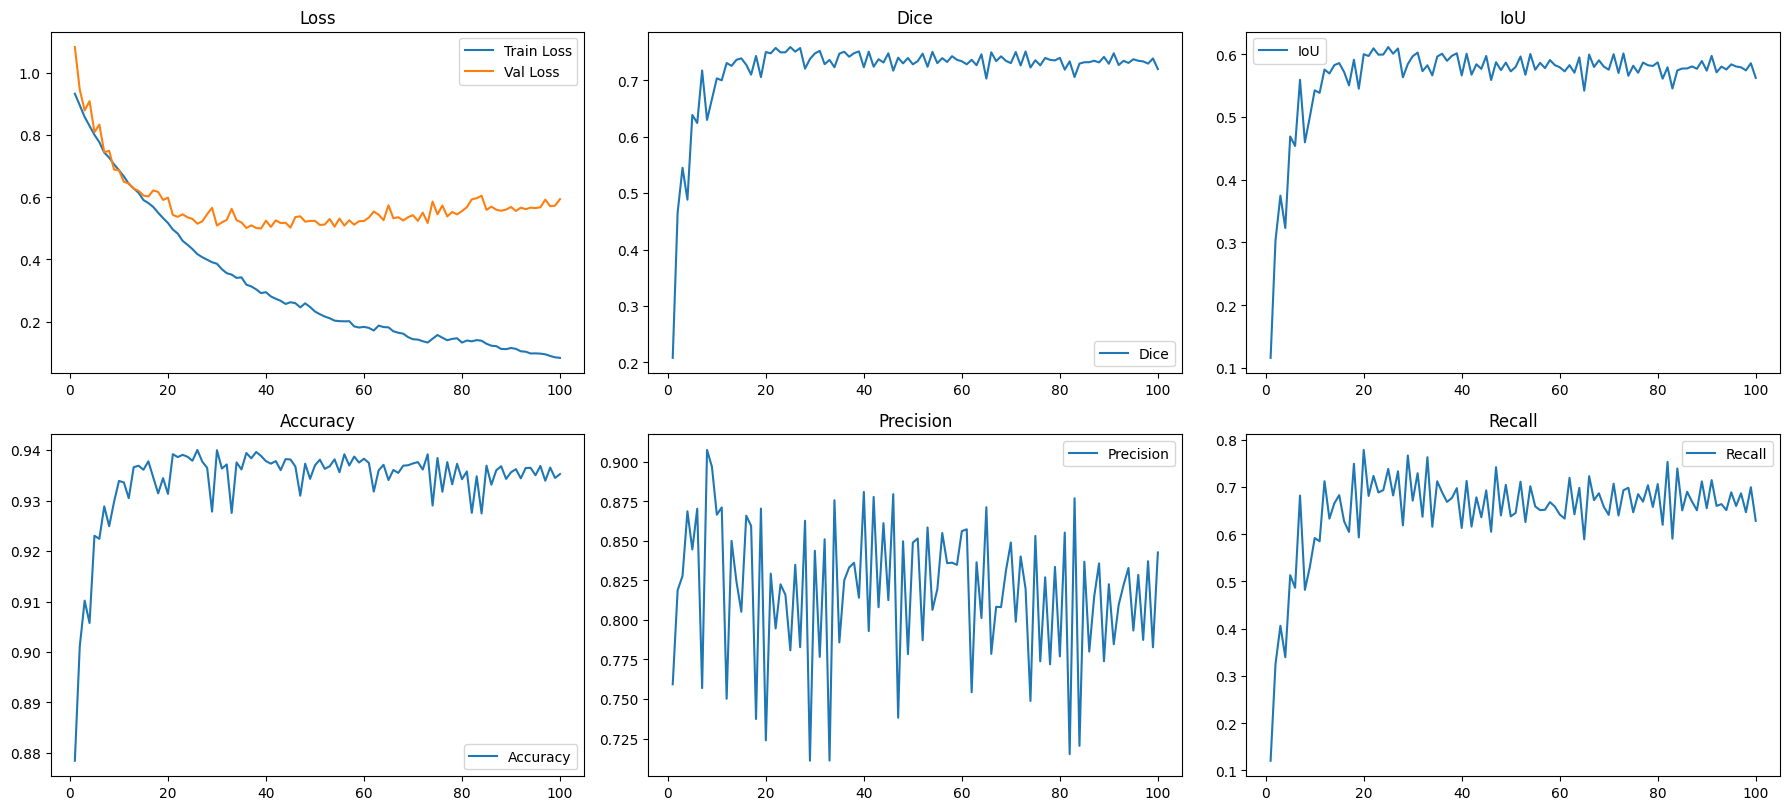

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

# ---- Loss ----
plt.subplot(3,3,1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# ---- Dice ----
plt.subplot(3,3,2)
plt.plot(history_df["epoch"], history_df["dice"], label="Dice")
plt.legend()
plt.title("Dice")

# ---- IoU ----
plt.subplot(3,3,3)
plt.plot(history_df["epoch"], history_df["jaccard"], label="IoU")
plt.legend()
plt.title("IoU")

# ---- Accuracy ----
plt.subplot(3,3,4)
plt.plot(history_df["epoch"], history_df["accuracy"], label="Accuracy")
plt.legend()
plt.title("Accuracy")

# ---- Precision ----
plt.subplot(3,3,5)
plt.plot(history_df["epoch"], history_df["precision"], label="Precision")
plt.legend()
plt.title("Precision")

# ---- Recall ----
plt.subplot(3,3,6)
plt.plot(history_df["epoch"], history_df["recall"], label="Recall")
plt.legend()
plt.title("Recall")

plt.tight_layout()
plt.show()

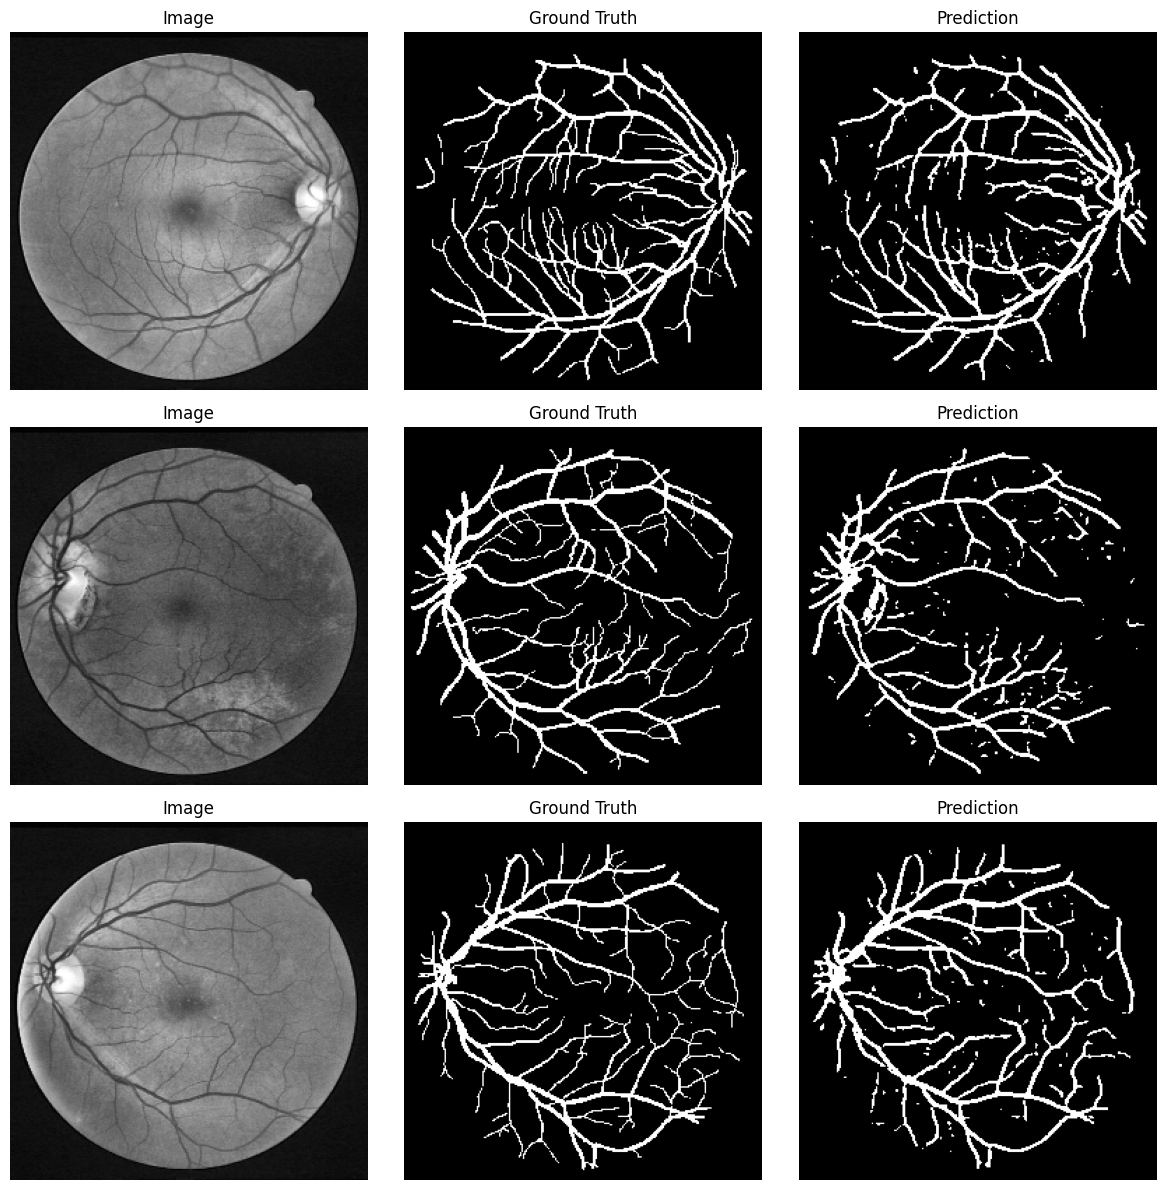

In [ ]:
def show_predictions(model, dataset, device, num_samples=3):
    model.eval()
    idxs = np.random.choice(len(dataset), num_samples, replace=False)

    plt.figure(figsize=(12, 4 * num_samples))

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, mask = dataset[idx]
            image_input = image.unsqueeze(0).to(device)

            pred = model(image_input)
            pred = torch.sigmoid(pred).squeeze().cpu().numpy()
            pred = (pred > 0.5).astype(np.uint8)

            img_np = image[0].cpu().numpy()
            mask_np = mask.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i*3+1)
            plt.imshow(img_np, cmap="gray")
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+3)
            plt.imshow(pred, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, cfg.device, num_samples=3)